# 🚚 Operational Analysis

Analyze delivery performance, ratings, and restaurant efficiency

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_data_full.csv")
df['order_date'] = pd.to_datetime(df['order_date'])

In [3]:
df.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days,has_discount,discount_value,discount_category,delay_category
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,2024-06,2,118.0,True,2023-01-24 16:01:00,505,True,6.36,0-10%,NaN
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,2023-11,5,50.0,True,2023-03-22 21:28:00,226,True,14.43,0-10%,Slow
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,2024-03,0,46.0,True,2023-01-25 10:37:00,410,True,60.42,20-50%,Slow
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,2023-10,0,128.0,True,2023-01-05 13:41:00,270,True,53.74,0-10%,NaN
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,2023-12,3,48.0,True,2023-05-14 01:40:00,214,True,22.18,10-20%,Slow


In [4]:
on_time_rate = (df['is_late_delivery'] == False).mean()*100
avg_delay = df['delivery_delay'].mean()
cancel_rate = (df['order_status'] != 'Delivered').mean()*100
avg_rating = df['rating'].mean()

print(on_time_rate, avg_delay, cancel_rate, avg_rating)

9.406078724464374 51.144195316392626 17.727952167414053 2.476952665670155


 ## INSIGHTS
Low on-time rate → delivery problem

High delay → poor logistics

High cancellation → demand mismatch

Low rating → bad experience

 ## O1: DELIVERY DELAY vs RATING 🔥

                delivery_delay   rating
delivery_delay         1.00000 -0.16741
rating                -0.16741  1.00000


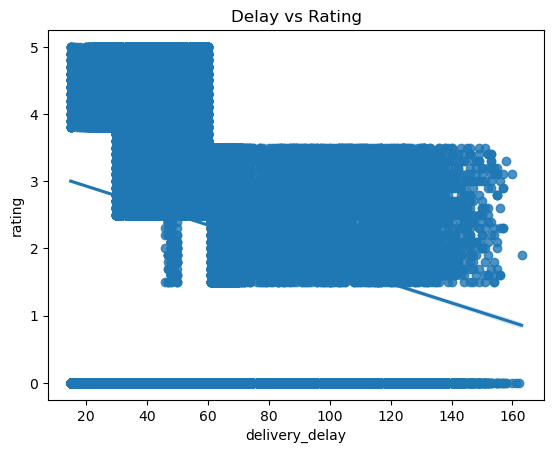

In [5]:
corr = df[['delivery_delay','rating']].corr()
print(corr)

sns.regplot(x='delivery_delay', y='rating', data=df)
plt.title("Delay vs Rating")
plt.show()

 ## 💡 INSIGHTS
Negative correlation confirms delay impacts satisfaction
Faster delivery = better ratings
 ## 🎯 BUSINESS VALUE

👉 Improve delivery → improve customer retention

## 2: AVG DELIVERY TIME BY CITY

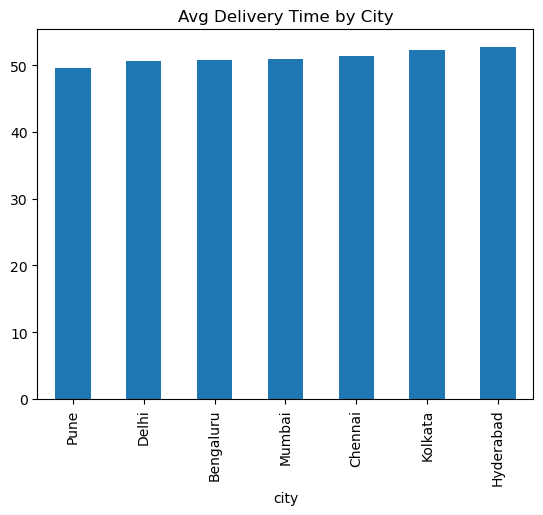

In [6]:
city_delay = df.groupby('city')['delivery_time_mins'].mean().sort_values()

city_delay.plot(kind='bar')
plt.title("Avg Delivery Time by City")
plt.show()

## 💡 INSIGHTS
Some cities consistently slower
Logistics inefficiency varies by region
🎯 BUSINESS VALUE

👉 Optimize delivery operations city-wise

 ## O3: RESTAURANT BENCHMARKING

In [7]:
rest = df.groupby('restaurant_name').agg({
    'delivery_delay':'mean',
    'rating':'mean'
})

top10 = rest.sort_values('rating', ascending=False).head(10)
bottom10 = rest.sort_values('rating').head(10)

top10, bottom10

(                                    delivery_delay    rating
 restaurant_name                                             
 Savant, Warrior and Khosla Kitchen       41.350000  3.127000
 Chokshi Inc Kitchen                      38.857143  3.110714
 Kapoor-Thakkar Kitchen                   45.972603  3.029452
 Shere, Vohra and Bahri Kitchen           43.144444  2.982778
 Badami-Subramaniam Kitchen               42.313433  2.970647
 Behl-Deep Kitchen                        40.427711  2.965060
 Nazareth-Sarna Kitchen                   40.675676  2.939459
 Bobal-Biswas Kitchen                     40.571429  2.904969
 Korpal, Hayre and Dewan Kitchen          39.750000  2.891892
 Barman-Nayak Kitchen                     42.913793  2.879885,
                                           delivery_delay    rating
 restaurant_name                                                   
 Dora-Majumdar Kitchen                          63.147887  1.977465
 Mukhopadhyay, Raja and Narayanan Kitchen       58.

 ## INSIGHTS
Top restaurants → fast + high rating
Bottom → slow + poor rating

🎯 BUSINESS VALUE

👉 Improve low performers / promote top ones

 ## O4: CANCELLATION RATE BY CUISINE

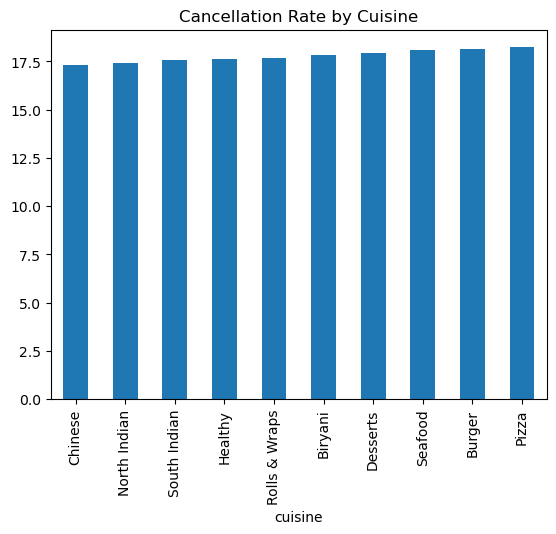

In [8]:
cancel = df.groupby('cuisine')['order_status'].apply(
    lambda x: (x != 'Delivered').mean()*100
).sort_values()

cancel.plot(kind='bar')
plt.title("Cancellation Rate by Cuisine")
plt.show()

 ## 💡 INSIGHTS
Certain cuisines have high cancellations
Likely due to prep complexity
🎯 BUSINESS VALUE

👉 Fix menu / prep / delivery issues

 ## O5: PREP TIME IMPACT

                    prep_time_mins  delivery_time_mins
prep_time_mins            1.000000            0.347056
delivery_time_mins        0.347056            1.000000


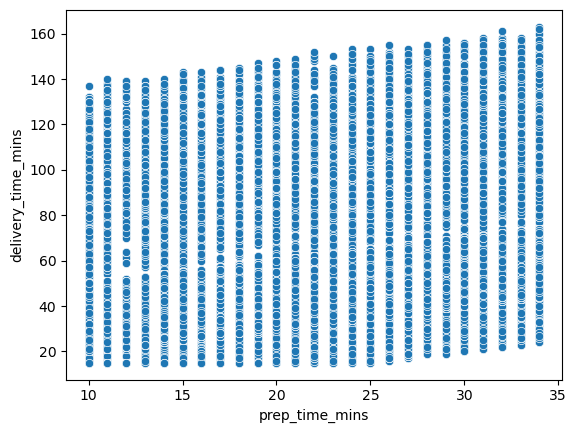

In [9]:
corr = df[['prep_time_mins','delivery_time_mins']].corr()
print(corr)

sns.scatterplot(x='prep_time_mins', y='delivery_time_mins', data=df)
plt.show()

 ## 💡 INSIGHTS
High prep time → longer delivery
Kitchen is bottleneck

🎯 BUSINESS VALUE

👉 Improve kitchen efficiency

 ## FINAL INSIGHTS 

## 🔍 Key Insights

- Delivery delay strongly impacts customer ratings  
- Certain cities and restaurants show poor performance  
- High cancellation cuisines indicate operational inefficiencies  
- Kitchen prep time significantly affects delivery speed  

## 🚀 Business Recommendations

- Improve delivery logistics in slow cities  
- Optimize restaurant operations for low performers  
- Reduce prep time for complex cuisines  
- Focus on on-time delivery to improve customer satisfaction